# Predicting Diabetes Using Naive Bayes

### Objective
- Apply Naive Bayes for binary classification.
- Practice data exploration and preprocessing.
- Evaluate model performance using appropriate metrics.
- Understand and interpret the log probabilities used in Naive Bayes.

### Dataset
This lab uses the Pima Indians Diabetes Dataset from the UCI Machine Learning Repository. It contains 8 features based on medical information, with a binary target indicating the presence of diabetes (1) or absence (0).

### Features
`Pregnancies`: Number of times pregnant
`Glucose`: Plasma glucose concentration
`BloodPressure`: Diastolic blood pressure (mm Hg)
`SkinThickness`: Triceps skinfold thickness (mm)
`Insulin`: 2-Hour serum insulin (mu U/ml)
`BMI`: Body mass index (weight in kg/(height in m)^2)
`DiabetesPedigreeFunction`: Diabetes pedigree function (a function based on family history)
`Age`: Age (years)
`Outcome`: Class variable (1 if patient has diabetes, 0 otherwise)

### Import packages

In [3]:
# Import the necessary libraries for data manipulation, model training, and evaluation.
# your code here

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

# This makes pandas tables easier to read in the notebook.
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### Data Loading and Exploration

In [4]:
# Load the Pima Indiands Diabetes Dataset in the folder ../data and preview the data
# Display summary statistics
# your code here

# Try different possible locations for the CSV file.
possible_paths = [
    Path("pima_diabetes.csv"),
    Path("data/pima_diabetes.csv"),
    Path("../data/pima_diabetes.csv"),
    Path("/mnt/data/pima_diabetes.csv")
]

csv_path = None
for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError("pima_diabetes.csv was not found. Put it next to this notebook or inside a data folder.")

diabetes = pd.read_csv(csv_path)

print(f"Dataset loaded from: {csv_path}")
print(f"Rows: {diabetes.shape[0]}")
print(f"Columns: {diabetes.shape[1]}")

diabetes.head()

Dataset loaded from: ../data/pima_diabetes.csv
Rows: 768
Columns: 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Outcome
No diabetes    500
Diabetes       268
Name: count, dtype: int64

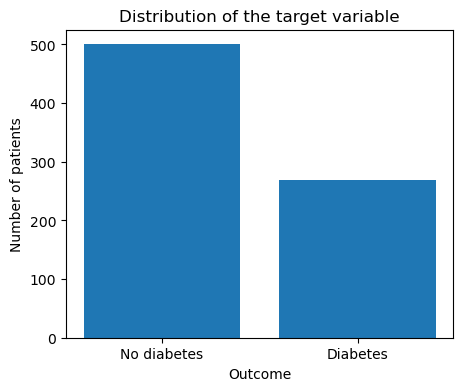

In [6]:
# Check the column names and data types.
# This helps confirm that the dataset was loaded correctly.
diabetes.info()
# Summary statistics of the numerical columns.
# I use this to detect strange values, for example zeros in medical measurements.
diabetes.describe().T
# Check the distribution of the target variable.
# This tells us how many patients are in each class.
outcome_counts = diabetes["Outcome"].value_counts().sort_index()

display(outcome_counts.rename(index={0: "No diabetes", 1: "Diabetes"}))

plt.figure(figsize=(5, 4))
plt.bar(["No diabetes", "Diabetes"], outcome_counts.values)
plt.title("Distribution of the target variable")
plt.ylabel("Number of patients")
plt.xlabel("Outcome")
plt.show()

### Data Cleaning

1. *Handling Missing Values*: Replace 0 values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns with their respective median values.
2. *Split Data*: Separate the feature columns (X) and target (y), and then split into training and test sets with an 80-20 split.

In [12]:
# your code here
# Columns where 0 is considered an unrealistic/missing value.
columns_with_zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count zero values before cleaning.
zero_counts_before = diabetes[columns_with_zero_as_missing].eq(0).sum()

# Make a copy so the original dataframe remains unchanged.
diabetes_clean = diabetes.copy()

# Replace zero values with the median of each column, ignoring zeros when calculating the median.
replacement_medians = {}

for column in columns_with_zero_as_missing:
    median_value = diabetes_clean.loc[diabetes_clean[column] != 0, column].median()
    replacement_medians[column] = median_value
    diabetes_clean[column] = diabetes_clean[column].replace(0, median_value)

print("Median values used to replace zeros:")
for column, median_value in replacement_medians.items():
    print(f"{column}: {median_value}")

# Confirm that the selected columns no longer contain zero values.
zero_counts_after = diabetes_clean[columns_with_zero_as_missing].eq(0).sum()
zero_counts_after
# Features: all columns except Outcome
X = diabetes_clean.drop("Outcome", axis=1)

# Target: the class to predict
y = diabetes_clean["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTarget distribution in training set:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTarget distribution in test set:")
display(y_test.value_counts(normalize=True).sort_index())

Median values used to replace zeros:
Glucose: 117.0
BloodPressure: 72.0
SkinThickness: 29.0
Insulin: 125.0
BMI: 32.3
Training set shape: (614, 8)
Test set shape: (154, 8)

Target distribution in training set:


Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


Target distribution in test set:


Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64

### Train a Naïve Bayes Classifier

Since the features are continuous, we need to use the `GaussianNB` model instead of the ones we used so far for categorical variables

In [13]:
# your code here
from sklearn.naive_bayes import GaussianNB
# Create the model
nb_classifier = GaussianNB()

# Train the model using the training data
nb_classifier.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")


Gaussian Naive Bayes model trained successfully.


### Model Evaluation

Evaluate the model's accuracy, precision and recall. Analyse the confusion matrix.
Give the setting of the problem, which metrics would you privilege?

Accuracy: 0.7013


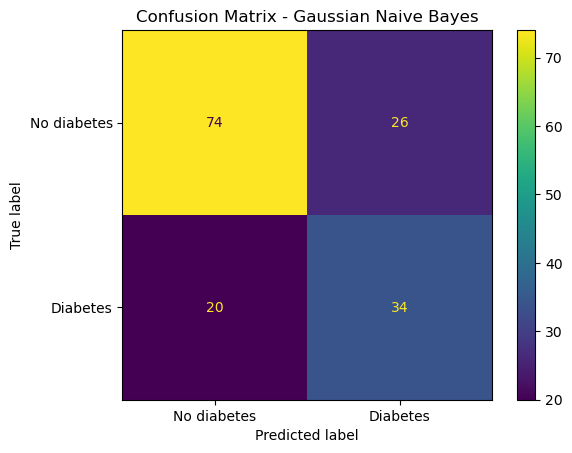

Confusion matrix:
[[74 26]
 [20 34]]


In [15]:
# your code here
# Predict the test set
y_pred = nb_classifier.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Detailed classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["No diabetes", "Diabetes"],
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df
# Confusion matrix for the original model.
# Rows = real labels, columns = predicted labels.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No diabetes", "Diabetes"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()

print("Confusion matrix:")
print(cm)
tn, fp, fn, tp = cm.ravel()

summary_metrics = pd.DataFrame({
    "Metric": [
        "True negatives",
        "False positives",
        "False negatives",
        "True positives",
        "Accuracy",
        "Precision for diabetes",
        "Recall for diabetes",
        "F1-score for diabetes"
    ],
    "Value": [
        tn,
        fp,
        fn,
        tp,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})


### Exploring Log Probabilities in Naïve Bayes

Naive Bayes calculates log probabilities (logprobs) for each class to make predictions. Let's use `predict_log_proba` to calculate the log probabilities for each class (diabetes vs. no diabetes) for a few samples in the test set.

Question: For a given instance in the test set, calculate the log probabilities for each class (diabetes vs. no diabetes) and interpret the values. How does Naive Bayes decide the predicted class based on these log probabilities?

In [16]:
# Select a few samples from the test set.
sample_indices = [0, 1, 12]
X_sample = X_test.iloc[sample_indices]

# Calculate log probabilities for each class.
log_probs = nb_classifier.predict_log_proba(X_sample)

# Also calculate normal probabilities to make the interpretation easier.
normal_probs = np.exp(log_probs)

log_probability_results = pd.DataFrame({
    "Sample position in X_test": sample_indices,
    "Log prob no diabetes": log_probs[:, 0],
    "Log prob diabetes": log_probs[:, 1],
    "Prob no diabetes": normal_probs[:, 0],
    "Prob diabetes": normal_probs[:, 1],
    "Predicted class": nb_classifier.predict(X_sample),
    "Real class": y_test.iloc[sample_indices].values
})

log_probability_results

,Sample position in X_test,Log prob no diabetes,Log prob diabetes,Prob no diabetes,Prob diabetes,Predicted class,Real class
0,0,-0.715594,-0.671193,0.488901,0.511099,1,0
1,1,-0.450819,-1.013645,0.637106,0.362894,0,0
2,12,-0.024633,-3.715971,0.975668,0.024332,0,0


- Interpretation of Log Probabilities: Log probabilities represent the logarithm of the probability for each class. A higher log probability (closer to zero, since log values are negative) indicates a higher likelihood for that class.
- Decision-Making: The model predicts the class with the highest log probability. If the log probability for Diabetes (1) is higher (closer to zero) than for No Diabetes (0), the model will predict Diabetes (1).

Convert log probabilities back to regular probabilities using np.exp(log_probs) to see how log transformations aid computation without changing predictions.

In [ ]:
# your code here
# Convert log probabilities back to regular probabilities using np.exp(log_probs) to see how log transformations aid computation without changing predictions.



Change your decision treshold so that either class 1 or 0 becomes more frequent in order to optimize your preferred metric (precision or recall) for this problem. Try multiple tresholds until you are satisfied with your choice.

In [17]:
treshold = 0.5 # adjust this number to make it easier/harder to classify someone as diabetic


# Calculate log probabilities for each class
log_probs = nb_classifier.predict_log_proba(X_test)

#compute probability of No Diabetes (0) vs Diabetes (1)
probabilities = []
for i, index in enumerate(X_test.index):
    prediction = 0 if np.exp(log_probs[i][0]) >= treshold else 1
    probabilities.append({'index':index,'no_diab_prob': np.exp(log_probs[i][0]), 'diab_prob': np.exp(log_probs[i][0]), 'prediction':prediction})

probabilities = pd.DataFrame(probabilities)
probabilities.head()

,index,no_diab_prob,diab_prob,prediction
0,44,0.488901,0.488901,1
1,672,0.637106,0.637106,0
2,700,0.812762,0.812762,0
3,630,0.899370,0.899370,0
4,81,0.986511,0.986511,0


In [ ]:
# create the confusion matrix for the adjusted problem
y_pred_adjusted = probabilities['prediction']
cm = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()